# Gruppeinnlevering




## Populasjonsvekst (logistisk modell)
Her har jeg laget et program, basert på en logistisk modell, som viser populasjonsvekst. Målet med dette var å se hvordan befolkningsveksten utviklet seg i de ulike landene.

Resultatet viser både total og relativ vekst i tre ulike land. Den viser også hvilket land som har hatt størst økning i befolkningen, og hvilket land som har størst populasjon. Utviklingen er også vist grafisk for alle tre land.

Økningen er størst i ('Sudan', 16063433)
Populasjonen er høyest i ('Sudan', 24063433)

Den totale veksten i Niger er 8975712
Den totale veksten i Sudan er 16063433
Den totale veksten i Djibouti er 8944434

Den relative veksten i Niger er 324.39 %
Den relative veksten i Sudan er 300.79 %
Den relative veksten i Djibouti er 186.81 %


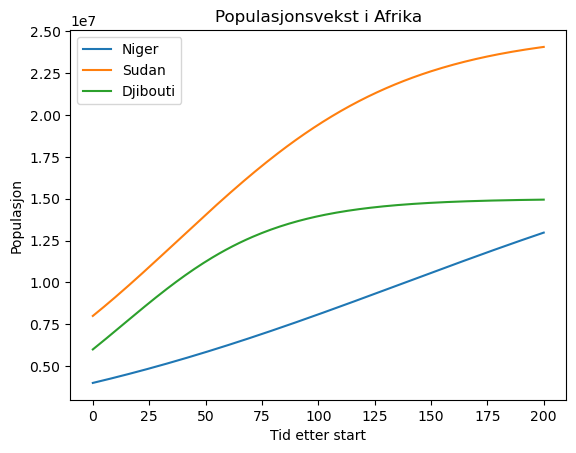

In [8]:
import math
import matplotlib.pyplot as plt
land = ["Niger", "Sudan", "Djibouti"]
K = [20e6, 25e6, 15e6] #Makspopulasjon
r = [0.01, 0.02, 0.03] #relativ vekstrate
P0 = [4e6, 8e6, 6e6] # Startpopulasjon
t = 200 #Hvor mange år vekst
t_liste = range(0, t+1) 

def logistisk_vekst(P0,K,r,t):
    A = (K-P0)/P0
    P = K/(1+A*math.exp(-r*t))
    return P

n_land = len(land)

data = []
for i in range(n_land):
    datapunkt = [land[i], P0[i], K[i], r[i]]
    data.append(datapunkt)

for datapunkt in data: 
    pop_vekst = []
    for t_i in t_liste:
        populasjon = logistisk_vekst(datapunkt[1], datapunkt[2], datapunkt[3], t_i)
        pop_vekst.append(populasjon)
    datapunkt.append(pop_vekst)

popS_0 = int(P0[0])
popSL_0 = int(data[0][-1][-1])
popS_1 = int(P0[1])
popSL_1 = int(data[1][-1][-1])
popS_2 = int(P0[2])
popSL_2 = int(data[2][-1][-1])

vekst_0 = int(popSL_0 - popS_0)
vekst_1 = int(popSL_1 - popS_1)
vekst_2 = int(popSL_2 - popS_2)

def storst_3(x0,x1,x2,land0,land1,land2):
    if x0 > x1:
        if x0 > x2:
            return land0, x0
        else:
            return land2, x2
    else:
        if x1 > x2:
            return land1, x1
        else: 
            return land2, x2

print("Økningen er størst i", storst_3(vekst_0, vekst_1, vekst_2, land[0], land[1], land[2]))
print("Populasjonen er høyest i", storst_3(popSL_0, popSL_1, popSL_2, land[0], land[1], land[2]))
print("")
print("Den totale veksten i", land[0], "er", vekst_0)
print("Den totale veksten i", land[1], "er", vekst_1)
print("Den totale veksten i", land[2], "er", vekst_2)
print("")
print("Den relative veksten i", land[0], "er", round(((popSL_0/popS_0)*100),2),"%")
print("Den relative veksten i", land[1], "er", round(((popSL_1/popS_1)*100),2),"%")
print("Den relative veksten i", land[2], "er", round(((popSL_2/popS_1)*100),2),"%")

for d in data:
    plt.plot(t_liste, d[-1], label=d[0])


plt.title("Populasjonsvekst i Afrika")
plt.xlabel("Tid etter start")
plt.ylabel("Populasjon")
plt.legend()
plt.show()


## Sparekalkulator

Her er en sparekalkulator som forteller deg om sparingen din er nok for ønsket sluttbeløp eller hvor lang tid det tar hvis det ikke er nok

terminbeløp 1000
rente 0.05
antall innskudd 12
ar 10
Ønsket sluttbeløp 100000



congratz bro, du har spart nok

Sluttbeløp 155282
Andel av sluttbeløp som er innskudd 120000 kr
Andel av sluttbeløp som er renter 35282 kr
Andel av sluttbeløp som er innskudd i prosent 77.28 %
Andel av sluttbeløp som er renter i prosent 22.72 %


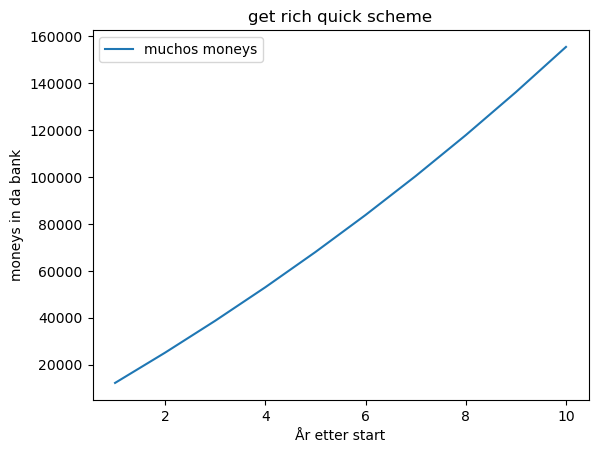

In [11]:
import matplotlib.pyplot as plt
import math
# Din kode her :)

terminbelop = int(input('terminbeløp'))
rente = float(input('rente'))
antall_innskudd = int(input('antall innskudd'))
ar = int(input('ar'))
onsket_sluttbelop = int(input('Ønsket sluttbeløp'))

ar_liste = []
penger_liste = []
tid = ar

def F(P,r,n,t):
    F = P * ((((1+(r/n))**(n*t))-1)/(r/n))
    return F

for i in range(tid):
    ar_liste.append(i+1)
    penger_liste.append(int(F(terminbelop,rente,antall_innskudd,i+1)))

sluttbelop = (int(F(terminbelop,rente,antall_innskudd,ar)))

z = onsket_sluttbelop - sluttbelop

print('')
if sluttbelop > onsket_sluttbelop:
    print('congratz bro, du har spart nok')
else:
    print('Du er',z,'kroner unna ønsket sluttbeløp')
    y = tid
    x = 0
    x2 = 0
    u = terminbelop
    while x < onsket_sluttbelop:
        x = (int(F(terminbelop,rente,antall_innskudd,y)))
        y = y + 1
    print('Det tar',y,'år for å nå det ønskede sluttbeløpet på',onsket_sluttbelop,'og da er sluttbelopet',x) 
    while x2 < onsket_sluttbelop:
        x2 = (int(F(u,rente,antall_innskudd,tid)))
        u = int(u * 1.01)
    print('Det tar et terminbeløp på',u,'for å nå det ønskede sluttbeløpet på',onsket_sluttbelop,', innen',tid,'år og da er sluttbelopet',x2) 
print('')

print('Sluttbeløp',int(F(terminbelop,rente,antall_innskudd,ar)))
print('Andel av sluttbeløp som er innskudd',terminbelop*antall_innskudd*ar,'kr')
print('Andel av sluttbeløp som er renter',(int(F(terminbelop,rente,antall_innskudd,ar)))-(terminbelop*antall_innskudd*ar),'kr')
print('Andel av sluttbeløp som er innskudd i prosent',round(((terminbelop*antall_innskudd*ar)/int(F(terminbelop,rente,antall_innskudd,ar))*100),2),'%')
print('Andel av sluttbeløp som er renter i prosent',round(((int(F(terminbelop,rente,antall_innskudd,ar)))-(terminbelop*antall_innskudd*ar))/int(F(terminbelop,rente,antall_innskudd,ar))*100,2),'%')

plt.plot(ar_liste,penger_liste, label = 'muchos moneys')
plt.title('get rich quick scheme')
plt.xlabel('År etter start')
plt.ylabel('moneys in da bank')

plt.legend()
plt.show()


## Resultat

terminbeløp - 5000
rente-  0.05
antall innskud- d 12
- ar 10
Ønsket sluttbeløp 500000

## Kundeadferd

Jeg har laget et program som sammenligner total omsetning når en butikk har tilbud med total omsetning uten tilbud.

Programmet lager også et histogram som viser hvor mange enheter av hvert produkt som blir solgt både med og uten tilbud.


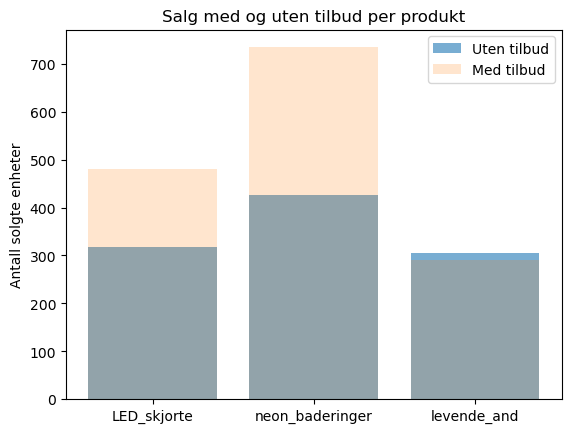

Total omsetning uten tilbud: 666200.00 NOK
Total omsetning med tilbud: 872600.00 NOK


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import random

#Pris uten tilbud
produkter = {
    "LED_skjorte": 600,
    "neon_baderinger": 400,
    "levende_and": 1000,
}

#Sannsynlighet for å kjøpe uten tilbud
start_sannsynlighet = {
    "LED_skjorte": 0.25,
    "neon_baderinger": 0.35,
    "levende_and": 0.70,
}

#Hvor mye øker sannsynligheten for å kjøpe når produktene er på salg
tilbudsrate = 1.75

#Simulering av en dag i butikken
def simuler_dag(antall_kunder, tilbud=False):
    total_omsetning = 0
    salg_per_produkt = {produkt: 0 for produkt in produkter}

    for _ in range(antall_kunder):
        budsjett = random.gauss(1000,500)
        for produkt, pris in produkter.items():
            if tilbud:
                sannsynlighet = start_sannsynlighet[produkt] * tilbudsrate
            else:
                sannsynlighet = start_sannsynlighet[produkt]

            #Kunde kjøper produkt hvis det er nok penger i budsjettet og tilfeldig verdi er under kjøpssannsynlighet
            if random.random() < sannsynlighet and budsjett >= pris:
                salg_per_produkt[produkt] += 1
                total_omsetning += pris
                budsjett -= pris

    return salg_per_produkt, total_omsetning


#Simulering av en måned med og uten tilbud
def simuler_maaned(antall_kunder_per_dag, tilbud=False):
    total_omsetning_maaned = 0
    totale_salg = {produkt: 0 for produkt in produkter}

    for _ in range(30):
        salg_per_dag, omsetning_per_dag = simuler_dag(antall_kunder_per_dag, tilbud)
        total_omsetning_maaned += omsetning_per_dag
        for produkt in produkter:
            totale_salg[produkt] += salg_per_dag[produkt]

    return totale_salg, total_omsetning_maaned

#Antall kunder per dag
antall_kunder_per_dag = 50

#Simulering av en måned uten tilbud
salg_uten_tilbud, omsetning_uten_tilbud = simuler_maaned(antall_kunder_per_dag, tilbud=False)

#Simulering av en måned med tilbud
salg_med_tilbud, omsetning_med_tilbud = simuler_maaned(antall_kunder_per_dag, tilbud=True)

#Plot resultater
produkter_liste = list(produkter.keys())
salg_u = [salg_uten_tilbud[produkt] for produkt in produkter_liste]
salg_m = [salg_med_tilbud[produkt] for produkt in produkter_liste]

x = np.arange(len(produkter_liste))
width = 0.35

#Salg uten tilbud
uten = plt.bar(produkter_liste, salg_u, label='Uten tilbud', alpha=0.6)
#Salg med tilbud
med = plt.bar(produkter_liste, salg_m, label='Med tilbud', alpha=0.2)

#Tekst, tittel og etiketter
plt.ylabel('Antall solgte enheter')
plt.title('Salg med og uten tilbud per produkt')
plt.legend()

plt.show()

#Sammenligning av total omsetning
print(f"Total omsetning uten tilbud: {omsetning_uten_tilbud:.2f} NOK")
print(f"Total omsetning med tilbud: {omsetning_med_tilbud:.2f} NOK")
